In [1]:
# для установки библиотеки ETNA
# !pip install etna[all]

# Data Preparation

In [2]:
import pandas as pd

from etna.datasets.tsdataset import TSDataset
from etna.transforms import (
    StandardScalerTransform,
    MeanTransform,
    LagTransform,
    DateFlagsTransform)


from etna.pipeline import Pipeline, AutoRegressivePipeline
from etna.metrics import SMAPE

import warnings
import numpy as np
import random
warnings.filterwarnings('ignore')

from etna.analysis import plot_forecast

def set_seed(seed: int = 42):
    """Set random seed for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)

set_seed()
smape = SMAPE()

C:\ProgramData\anaconda3\envs\etna_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
HORIZON = 90
CONSIDER_SHOP = [1, 2, 3]
SEGMENTS_TO_SHOW = ['3 + 27' , '1 + 47'] # просто рандомные сегменты для построения графика прогноза


In [4]:
def train_and_evaluate_model(ts,
                             model,
                             transforms,
                             horizon,
                             metrics,
                             is_auto_regressive = False,
                             print_metrics=True,
                             return_forecast=False,
                             n_train_samples = 360 * 2,
                             segments_to_plot=SEGMENTS_TO_SHOW,
                         ):
    """"
    Обучает модель, вычисляет прогнозы для
    тестовой выборки и строит график прогнозов.
    """

    import copy

    ts_copy = copy.deepcopy(ts)
    train_ts, test_ts = ts_copy.train_test_split(test_size=horizon)

    if not is_auto_regressive:
        pipe = Pipeline(model=model,
                        transforms=transforms,
                        horizon=horizon)

    else:
        pipe = AutoRegressivePipeline(model = model,
                                      transforms=transforms,
                                      horizon=horizon)

    pipe.fit(train_ts)
    forecast_ts = pipe.forecast()

    # оцениваем качество прогнозов по сегментам
    segment_metrics = metrics(test_ts, forecast_ts)
    segment_metrics = pd.Series(segment_metrics)

    avg_metric = sum(segment_metrics) / len(segment_metrics)

    if print_metrics:
        print(f"Avg (by segments) metric {metrics} is: {avg_metric}")

    if segments_to_plot:
        plot_forecast(forecast_ts, test_ts,
                      train_ts, n_train_samples=n_train_samples, segments=segments_to_plot)

    if return_forecast:
        return segment_metrics, avg_metric, forecast_ts

    return segment_metrics, avg_metric

In [5]:
df = pd.read_csv('HW_train.csv', parse_dates=['date'])

df.rename(columns={'date': 'timestamp',
                   'sales': 'target'}, inplace=True)
df

,timestamp,store,item,target
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10
...,...,...,...,...
912995,2017-12-27,10,50,63
912996,2017-12-28,10,50,59
912997,2017-12-29,10,50,74
912998,2017-12-30,10,50,62


In [6]:
# уменьшаем размер данных, чтобы не тратить много времени на обучение
before_shape = df.shape
print('before', before_shape)
df = df[df.store.isin(CONSIDER_SHOP)]  # Оставлены только магазины 1, 2, 3
print('before', df.shape)

print(f"Current dataset size {df.shape[0] * 100 / before_shape[0]}%")

before (913000, 4)
before (273900, 4)
Current dataset size 30.0%


In [7]:
df_new = pd.read_csv('HW_test.csv', parse_dates=['date'])
df_new = df_new[df_new.store.isin(CONSIDER_SHOP)]

df_new.rename(columns={'date': 'timestamp',
                   'sales': 'target'}, inplace=True)


df_new.drop(columns='id', inplace=True)

df_new

,timestamp,store,item
0,2018-01-01,1,1
1,2018-01-02,1,1
2,2018-01-03,1,1
3,2018-01-04,1,1
4,2018-01-05,1,1
...,...,...,...
44365,2018-03-27,3,50
44366,2018-03-28,3,50
44367,2018-03-29,3,50
44368,2018-03-30,3,50


In [8]:
# объединяет магазин и товар
df['segment'] = (df['store'].astype(str) + ' + '
                 + df['item'].astype(str))

df_new['segment'] = (df_new['store'].astype(str) + ' + '
                     + df_new['item'].astype(str))

df.head()

,timestamp,store,item,target,segment
0,2013-01-01,1,1,13,1 + 1
1,2013-01-02,1,1,11,1 + 1
2,2013-01-03,1,1,14,1 + 1
3,2013-01-04,1,1,13,1 + 1
4,2013-01-05,1,1,10,1 + 1


In [9]:
for col in ['store', 'item']:
    df[col] = df[col].astype('category')
    df_new[col] = df_new[col].astype('category')

In [10]:
regressor_df = df[['timestamp', 'segment', 'store', 'item']].copy()
regressor_df

,timestamp,segment,store,item
0,2013-01-01,1 + 1,1,1
1,2013-01-02,1 + 1,1,1
2,2013-01-03,1 + 1,1,1
3,2013-01-04,1 + 1,1,1
4,2013-01-05,1 + 1,1,1
...,...,...,...,...
900213,2017-12-27,3 + 50,3,50
900214,2017-12-28,3 + 50,3,50
900215,2017-12-29,3 + 50,3,50
900216,2017-12-30,3 + 50,3,50


In [11]:
# экзогенные переменные store и item
regressor_df_new = df_new.copy()
regressor_df_new

,timestamp,store,item,segment
0,2018-01-01,1,1,1 + 1
1,2018-01-02,1,1,1 + 1
2,2018-01-03,1,1,1 + 1
3,2018-01-04,1,1,1 + 1
4,2018-01-05,1,1,1 + 1
...,...,...,...,...
44365,2018-03-27,3,50,3 + 50
44366,2018-03-28,3,50,3 + 50
44367,2018-03-29,3,50,3 + 50
44368,2018-03-30,3,50,3 + 50


In [12]:
regressor_df = regressor_df.sort_index(
    axis=1, ascending=False)

regressor_df_new = regressor_df_new.sort_index(
    axis=1, ascending=False)

In [13]:
regressor_df.shape, regressor_df_new.shape, regressor_df.shape[0] + regressor_df_new.shape[0]

((273900, 4), (13500, 4), 287400)

In [14]:
regressor_df.columns, regressor_df_new.columns

(Index(['timestamp', 'store', 'segment', 'item'], dtype='object'),
 Index(['timestamp', 'store', 'segment', 'item'], dtype='object'))

In [15]:
regressor_df = pd.concat([regressor_df, regressor_df_new], axis=0)

regressor_df['quarter'] = regressor_df['timestamp'].dt.quarter
regressor_df['quarter_start'] = regressor_df['timestamp'].dt.is_quarter_start
regressor_df['quarter_end'] = regressor_df['timestamp'].dt.is_quarter_end
regressor_df

,timestamp,store,segment,item,quarter,quarter_start,quarter_end
0,2013-01-01,1,1 + 1,1,1,True,False
1,2013-01-02,1,1 + 1,1,1,False,False
2,2013-01-03,1,1 + 1,1,1,False,False
3,2013-01-04,1,1 + 1,1,1,False,False
4,2013-01-05,1,1 + 1,1,1,False,False
...,...,...,...,...,...,...,...
44365,2018-03-27,3,3 + 50,50,1,False,False
44366,2018-03-28,3,3 + 50,50,1,False,False
44367,2018-03-29,3,3 + 50,50,1,False,False
44368,2018-03-30,3,3 + 50,50,1,False,False


In [16]:
# подготавливаем исторический набор эндогенных переменных
df.drop(['store', 'item'], axis=1, inplace=True)
df

,timestamp,target,segment
0,2013-01-01,13,1 + 1
1,2013-01-02,11,1 + 1
2,2013-01-03,14,1 + 1
3,2013-01-04,13,1 + 1
4,2013-01-05,10,1 + 1
...,...,...,...
900213,2017-12-27,52,3 + 50
900214,2017-12-28,75,3 + 50
900215,2017-12-29,68,3 + 50
900216,2017-12-30,62,3 + 50


In [17]:
# Данные переводятся в формат ETNA
df = TSDataset.to_dataset(df)
df

segment,1 + 1,1 + 10,1 + 11,1 + 12,1 + 13,1 + 14,1 + 15,1 + 16,1 + 17,1 + 18,...,3 + 46,3 + 47,3 + 48,3 + 49,3 + 5,3 + 50,3 + 6,3 + 7,3 + 8,3 + 9
feature,target,target,target,target,target,target,target,target,target,target,...,target,target,target,target,target,target,target,target,target,target
timestamp,,,,,,,,,,,,,,,,,,,,,
2013-01-01,13.0,37.0,37.0,33.0,37.0,22.0,42.0,14.0,13.0,38.0,...,33.0,10.0,28.0,21.0,13.0,45.0,34.0,40.0,54.0,28.0
2013-01-02,11.0,34.0,43.0,35.0,31.0,35.0,33.0,11.0,18.0,51.0,...,46.0,12.0,32.0,14.0,9.0,47.0,38.0,36.0,34.0,16.0
2013-01-03,14.0,32.0,34.0,41.0,50.0,26.0,45.0,12.0,15.0,42.0,...,37.0,13.0,40.0,22.0,10.0,39.0,32.0,36.0,61.0,32.0
2013-01-04,13.0,45.0,52.0,45.0,45.0,32.0,39.0,15.0,19.0,50.0,...,32.0,5.0,39.0,26.0,20.0,48.0,36.0,38.0,38.0,40.0
2013-01-05,10.0,35.0,45.0,46.0,49.0,31.0,47.0,22.0,16.0,56.0,...,41.0,14.0,47.0,22.0,13.0,46.0,36.0,31.0,54.0,44.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-12-27,14.0,55.0,43.0,47.0,49.0,42.0,62.0,16.0,29.0,54.0,...,60.0,21.0,42.0,23.0,17.0,52.0,53.0,53.0,67.0,46.0
2017-12-28,19.0,63.0,64.0,49.0,68.0,51.0,82.0,24.0,13.0,69.0,...,72.0,19.0,52.0,38.0,21.0,75.0,55.0,53.0,80.0,61.0


In [18]:
regressor_df = TSDataset.to_dataset(regressor_df)
regressor_df

segment    1 + 1                                         1 + 10          \
feature     item quarter quarter_end quarter_start store   item quarter   
timestamp                                                                 
2013-01-01     1       1       False          True     1     10       1   
2013-01-02     1       1       False         False     1     10       1   
2013-01-03     1       1       False         False     1     10       1   
2013-01-04     1       1       False         False     1     10       1   
2013-01-05     1       1       False         False     1     10       1   
...          ...     ...         ...           ...   ...    ...     ...   
2018-03-27     1       1       False         False     1     10       1   
2018-03-28     1       1       False         False     1     10       1   
2018-03-29     1       1       False         False     1     10       1   
2018-03-30     1       1       False         False     1     10       1   
2018-03-31     1       1        True         False     1     10       1   

segment                                     ... 3 + 8                      \
feature    quarter_end quarter_start store  ...  item quarter quarter_end   
timestamp                                   ...                             
2013-01-01       False          True     1  ...     8       1       False   
2013-01-02       False         False     1  ...     8       1       False   
2013-01-03       False         False     1  ...     8       1       False   
2013-01-04       False         False     1  ...     8       1       False   
2013-01-05       False         False     1  ...     8       1       False   
...                ...           ...   ...  ...   ...     ...         ...   
2018-03-27       False         False     1  ...     8       1       False   
2018-03-28       False         False     1  ...     8       1       False   
2018-03-29       False         False     1  ...     8       1       False   
2018-03-30       False         False     1  ...     8       1       False   
2018-03-31        True         False     1  ...     8       1        True   

segment                        3 + 9                                          
feature    quarter_start store  item quarter quarter_end quarter_start store  
timestamp                                                                     
2013-01-01          True     3     9       1       False          True     3  
2013-01-02         False     3     9       1       False         False     3  
2013-01-03         False     3     9       1       False         False     3  
2013-01-04         False     3     9       1       False         False     3  
2013-01-05         False     3     9       1       False         False     3  
...                  ...   ...   ...     ...         ...           ...   ...  
2018-03-27         False     3     9       1       False         False     3  
2018-03-28         False     3     9       1       False         False     3  
2018-03-29         False     3     9       1       False         False     3  
2018-03-30         False     3     9       1       False         False     3  
2018-03-31         False     3     9       1        True         False     3  

[1916 rows x 750 columns]

In [19]:
# создаём объединённый набор
ts = TSDataset(df=df, freq='D', df_exog=regressor_df,
               known_future='all')
ts

segment    1 + 1                                                1 + 10  \
feature     item quarter quarter_end quarter_start store target   item   
timestamp                                                                
2013-01-01     1       1       False          True     1   13.0     10   
2013-01-02     1       1       False         False     1   11.0     10   
2013-01-03     1       1       False         False     1   14.0     10   
2013-01-04     1       1       False         False     1   13.0     10   
2013-01-05     1       1       False         False     1   10.0     10   
...          ...     ...         ...           ...   ...    ...    ...   
2017-12-27     1       4       False         False     1   14.0     10   
2017-12-28     1       4       False         False     1   19.0     10   
2017-12-29     1       4       False         False     1   15.0     10   
2017-12-30     1       4       False         False     1   27.0     10   
2017-12-31     1       4        True         False     1   23.0     10   

segment                                       ...       3 + 8                \
feature    quarter quarter_end quarter_start  ... quarter_end quarter_start   
timestamp                                     ...                             
2013-01-01       1       False          True  ...       False          True   
2013-01-02       1       False         False  ...       False         False   
2013-01-03       1       False         False  ...       False         False   
2013-01-04       1       False         False  ...       False         False   
2013-01-05       1       False         False  ...       False         False   
...            ...         ...           ...  ...         ...           ...   
2017-12-27       4       False         False  ...       False         False   
2017-12-28       4       False         False  ...       False         False   
2017-12-29       4       False         False  ...       False         False   
2017-12-30       4       False         False  ...       False         False   
2017-12-31       4        True         False  ...        True         False   

segment                 3 + 9                                                 
feature    store target  item quarter quarter_end quarter_start store target  
timestamp                                                                     
2013-01-01     3   54.0     9       1       False          True     3   28.0  
2013-01-02     3   34.0     9       1       False         False     3   16.0  
2013-01-03     3   61.0     9       1       False         False     3   32.0  
2013-01-04     3   38.0     9       1       False         False     3   40.0  
2013-01-05     3   54.0     9       1       False         False     3   44.0  
...          ...    ...   ...     ...         ...           ...   ...    ...  
2017-12-27     3   67.0     9       4       False         False     3   46.0  
2017-12-28     3   80.0     9       4       False         False     3   61.0  
2017-12-29     3   71.0     9       4       False         False     3   54.0  
2017-12-30     3   87.0     9       4       False         False     3   48.0  
2017-12-31     3   76.0     9       4        True         False     3   58.0  

[1826 rows x 900 columns]

# Data Analysis

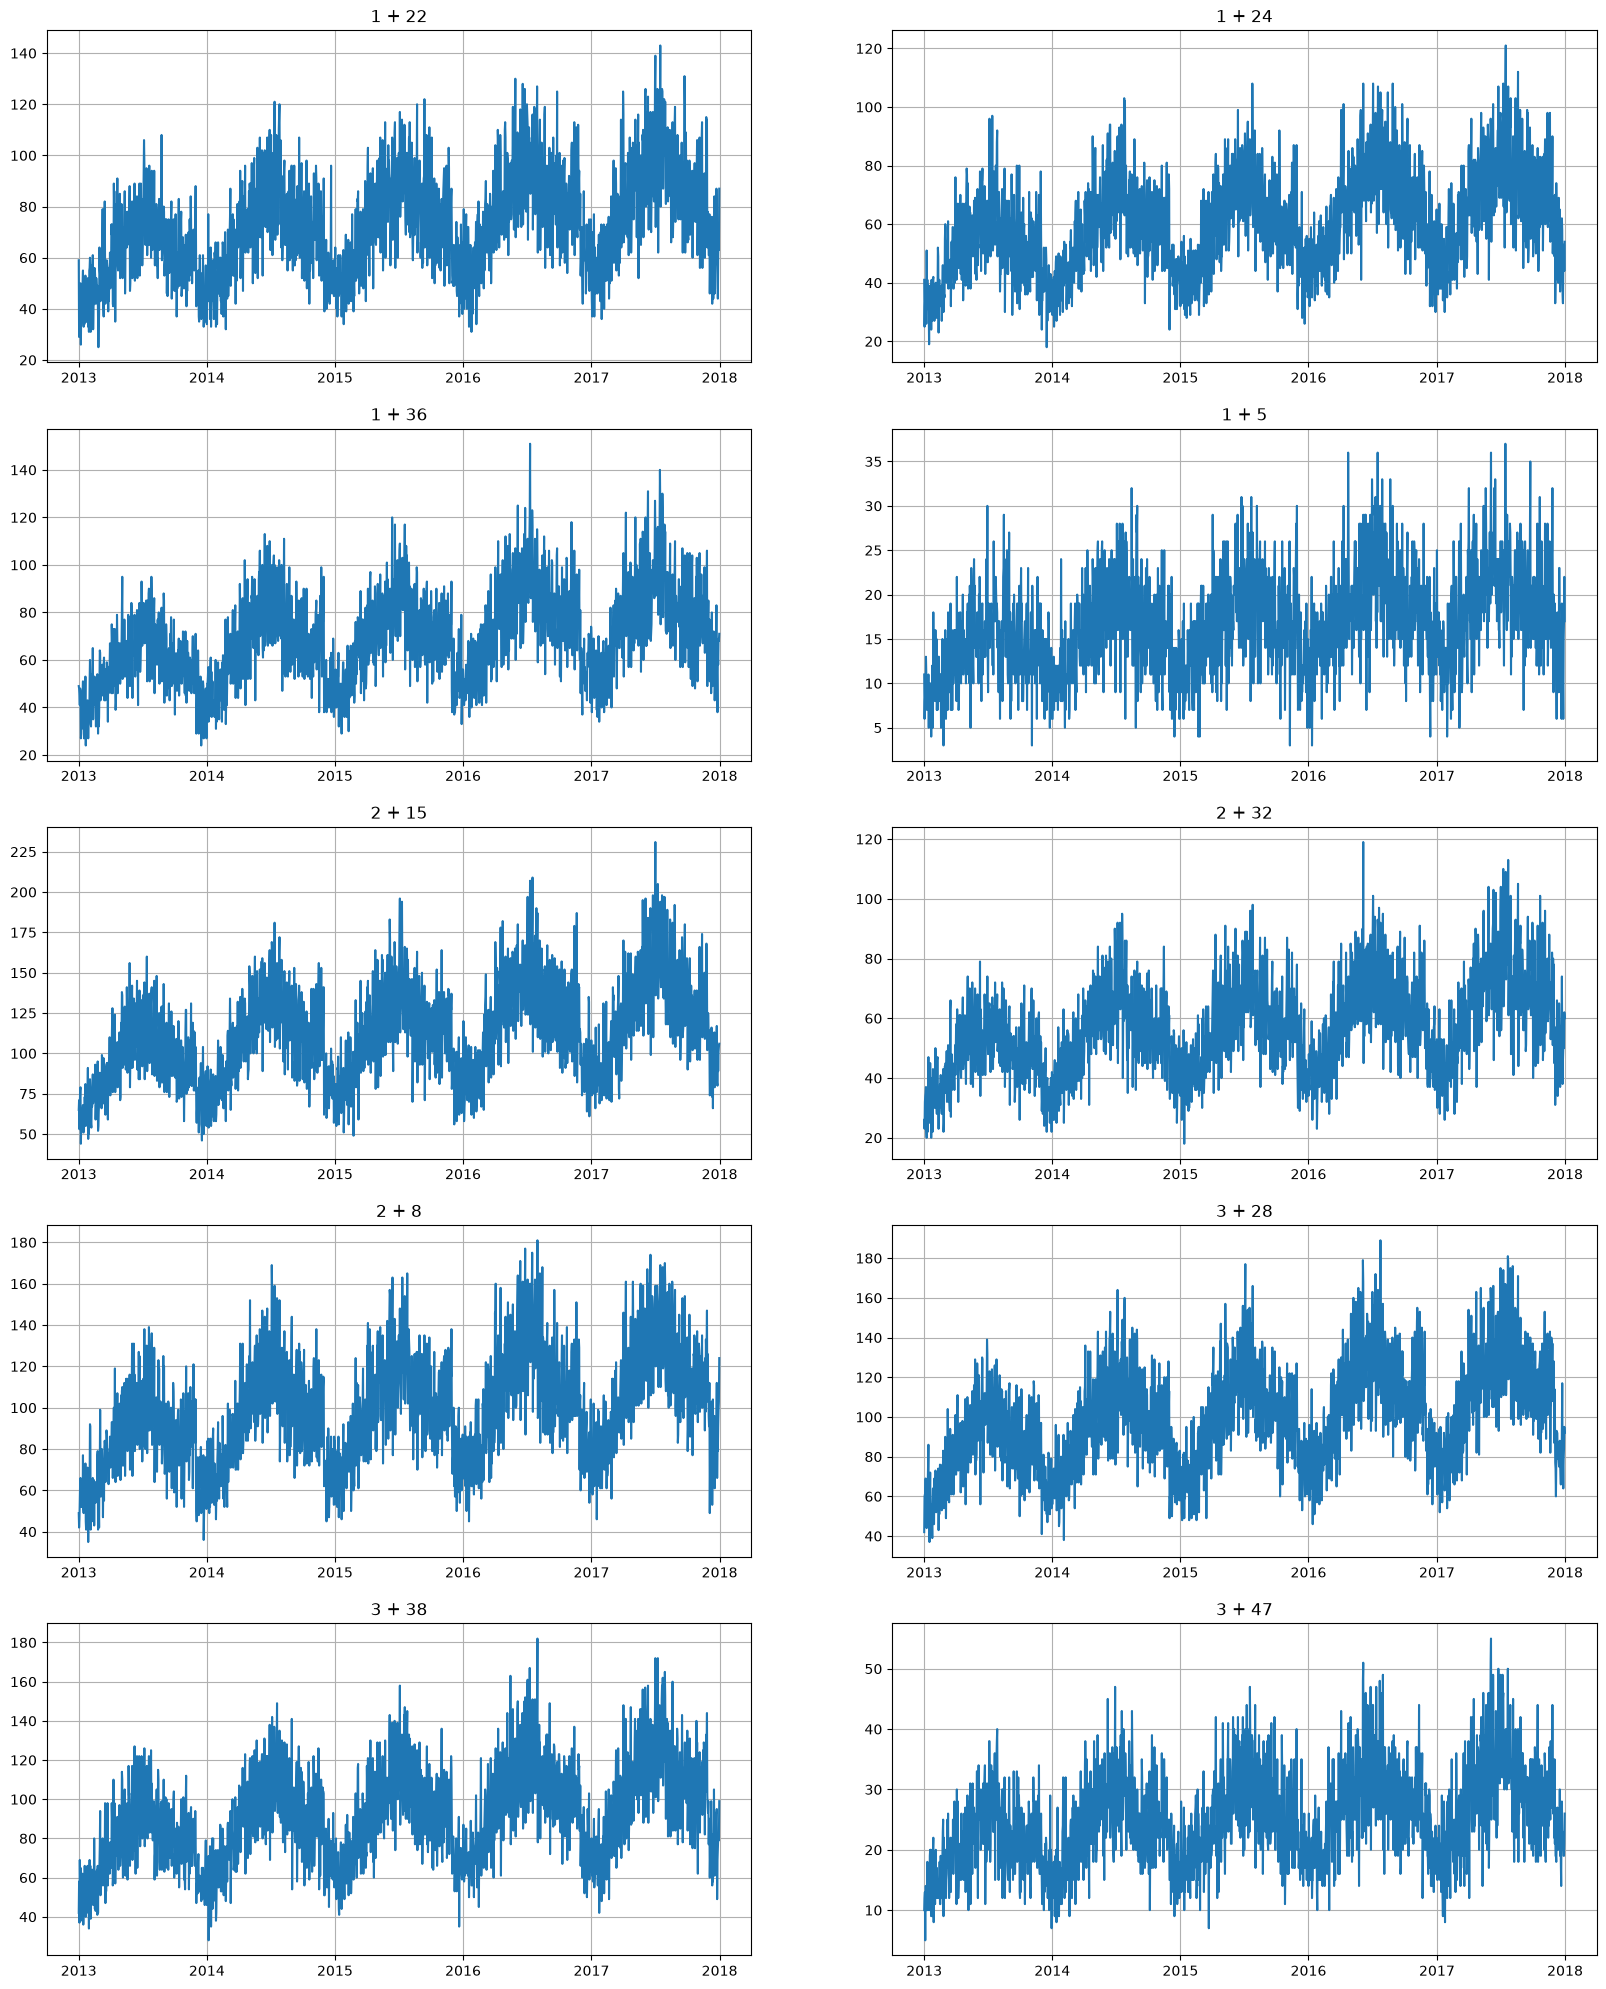

In [20]:
ts.plot()

In [21]:
ts.describe()

,start_timestamp,end_timestamp,length,num_missing,num_segments,num_exogs,num_regressors,num_known_future,freq
segments,,,,,,,,,
1 + 1,2013-01-01,2017-12-31,1826,0,150,5,5,5,D
1 + 10,2013-01-01,2017-12-31,1826,0,150,5,5,5,D
1 + 11,2013-01-01,2017-12-31,1826,0,150,5,5,5,D
1 + 12,2013-01-01,2017-12-31,1826,0,150,5,5,5,D
1 + 13,2013-01-01,2017-12-31,1826,0,150,5,5,5,D
...,...,...,...,...,...,...,...,...,...
3 + 50,2013-01-01,2017-12-31,1826,0,150,5,5,5,D
3 + 6,2013-01-01,2017-12-31,1826,0,150,5,5,5,D
3 + 7,2013-01-01,2017-12-31,1826,0,150,5,5,5,D


In [22]:
from etna.analysis import acf_plot
from etna.analysis import plot_correlation_matrix

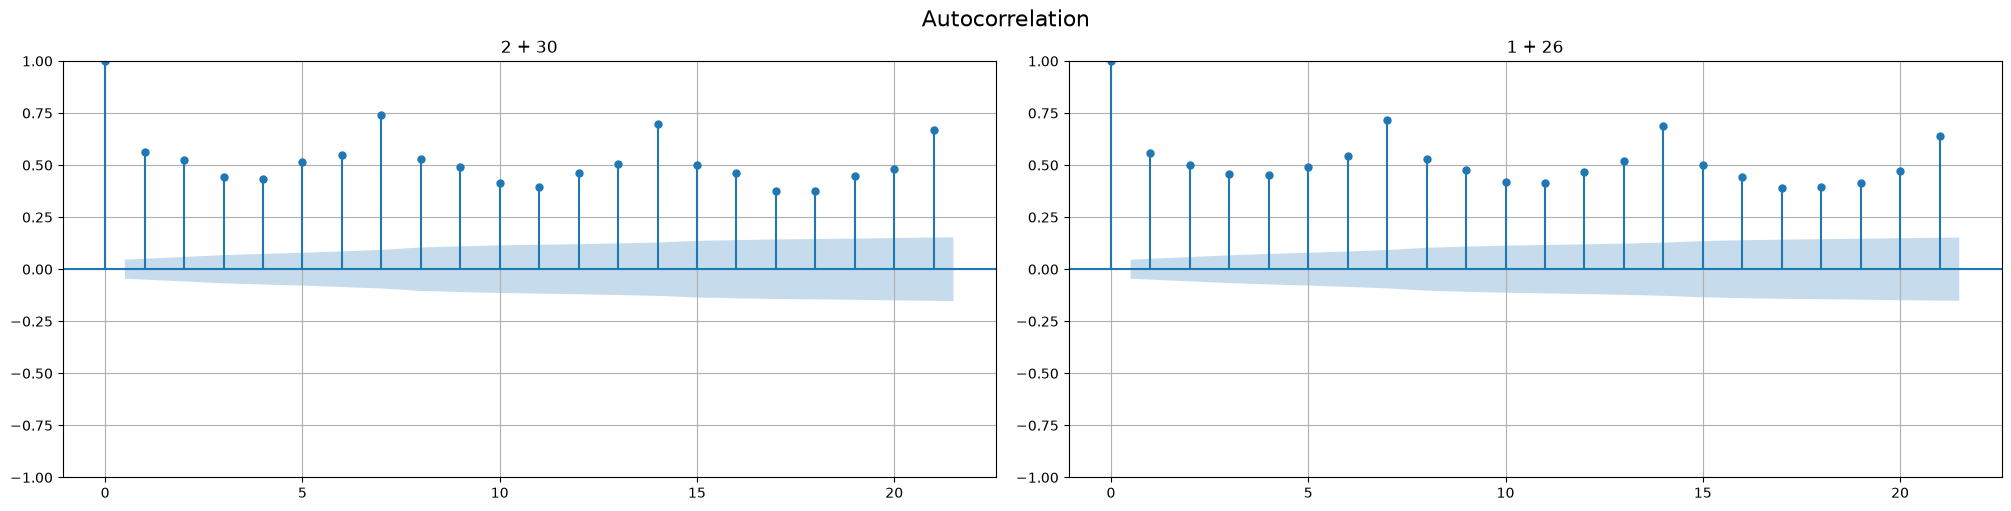

In [23]:
acf_plot(ts, lags=21, n_segments=2)

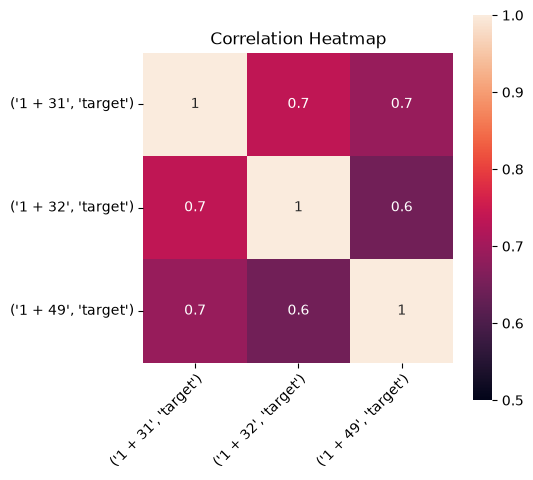

In [24]:
plot_correlation_matrix(ts, columns=['target'], segments=['1 + 31', "1 + 32", "1 + 49"],
                        method="spearman", vmin=0.5, vmax=1, figsize=(5,5))

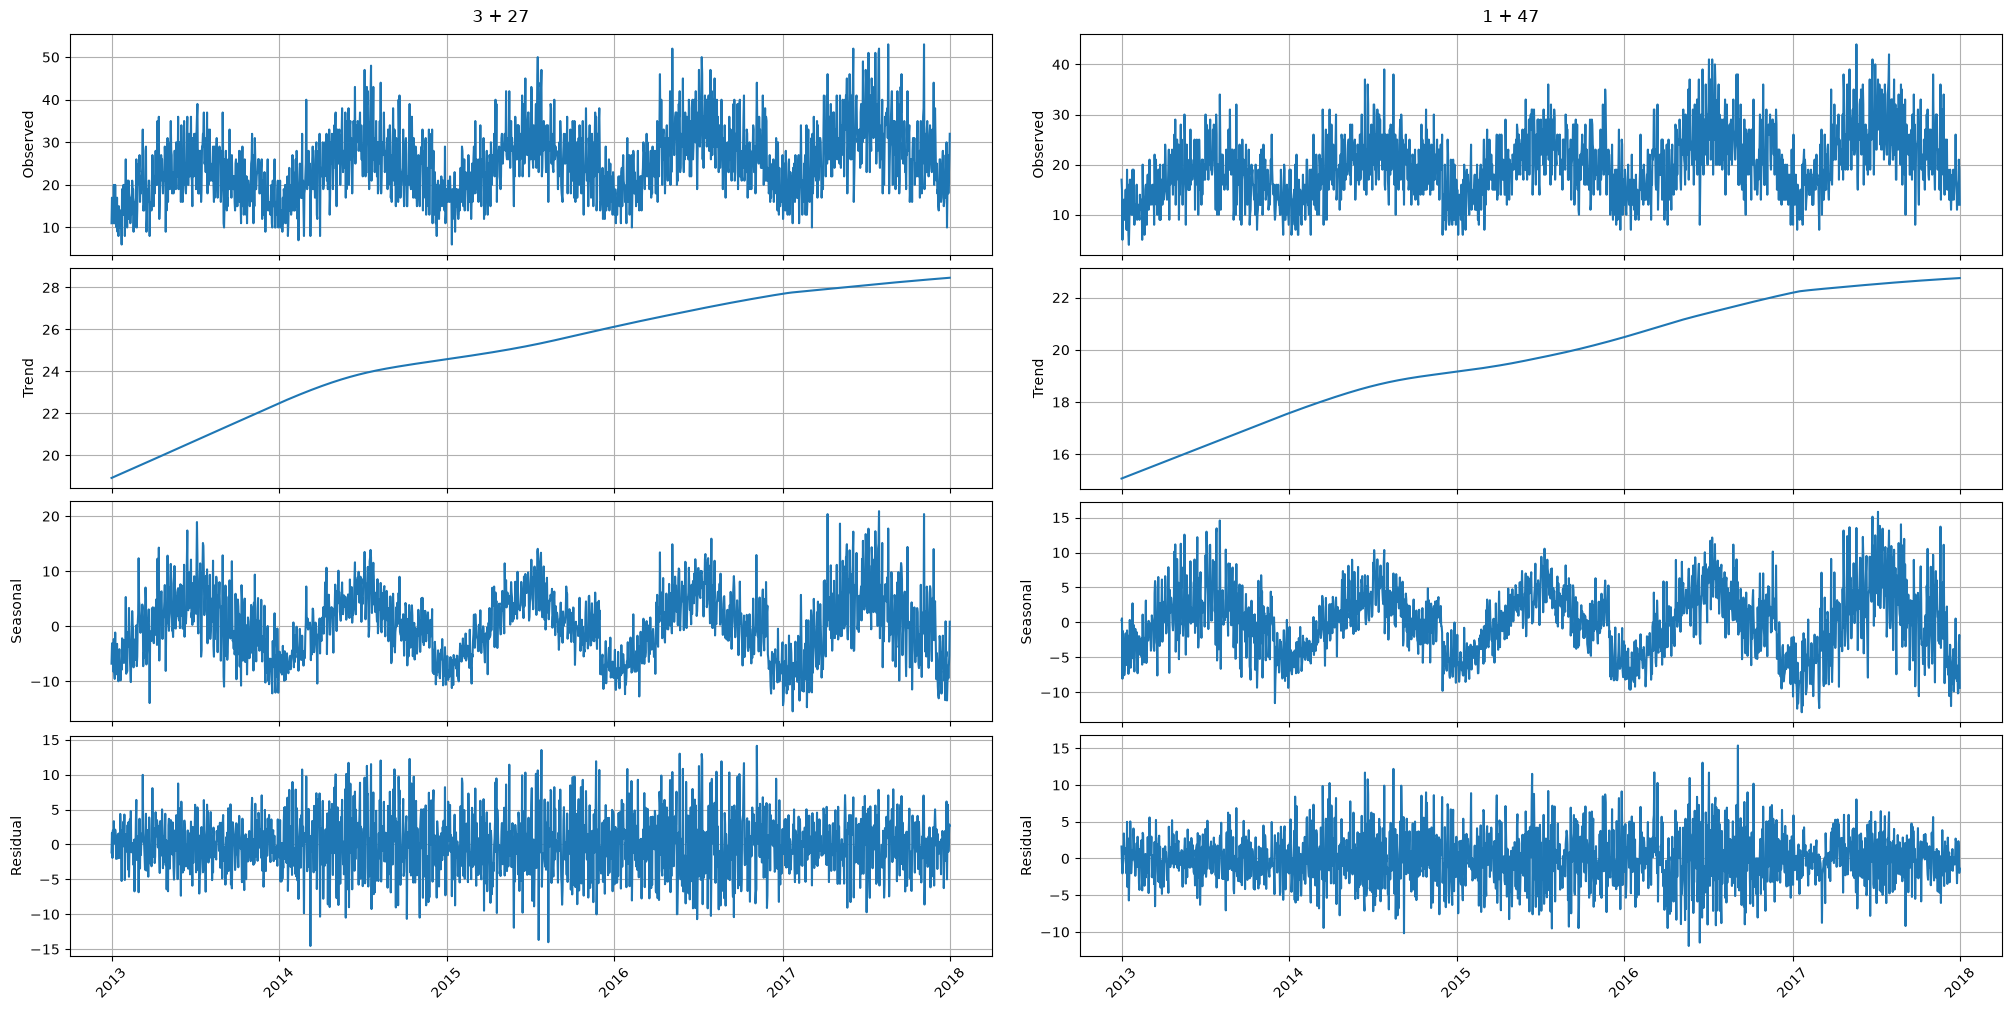

In [25]:
from etna.analysis import stl_plot

stl_plot(ts=ts, period=365, segments=SEGMENTS_TO_SHOW)

# 0. Naive Model

Avg (by segments) metric SMAPE(mode = 'per-segment', missing_mode = 'error', ) is: 27.94174347082239


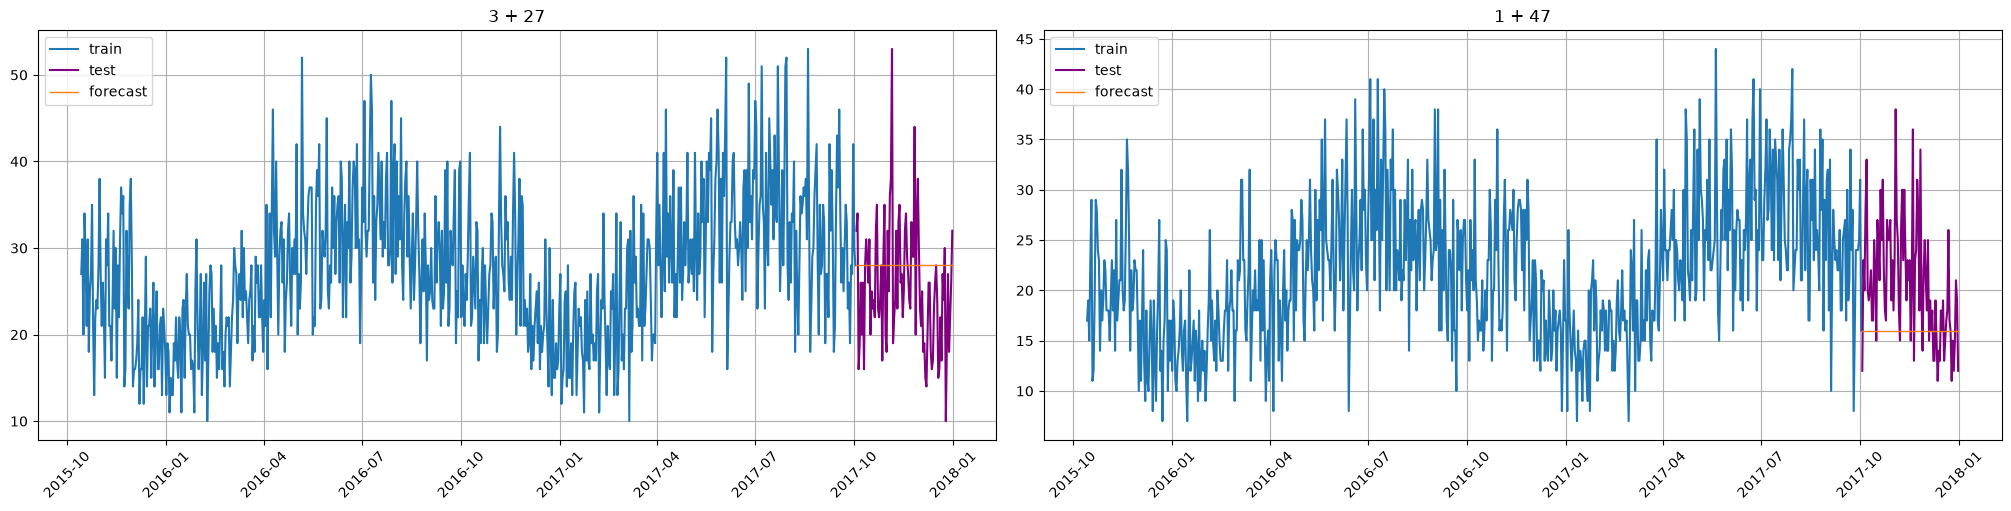

In [26]:
from etna.models import NaiveModel

naive_model_recursive_metrics = train_and_evaluate_model(
    ts=ts,
    model=NaiveModel(),
    transforms=[],
    horizon=HORIZON,
    metrics=smape,
    is_auto_regressive=True,
    print_metrics=True,
    )

Avg (by segments) metric SMAPE(mode = 'per-segment', missing_mode = 'error', ) is: 27.94174347082239


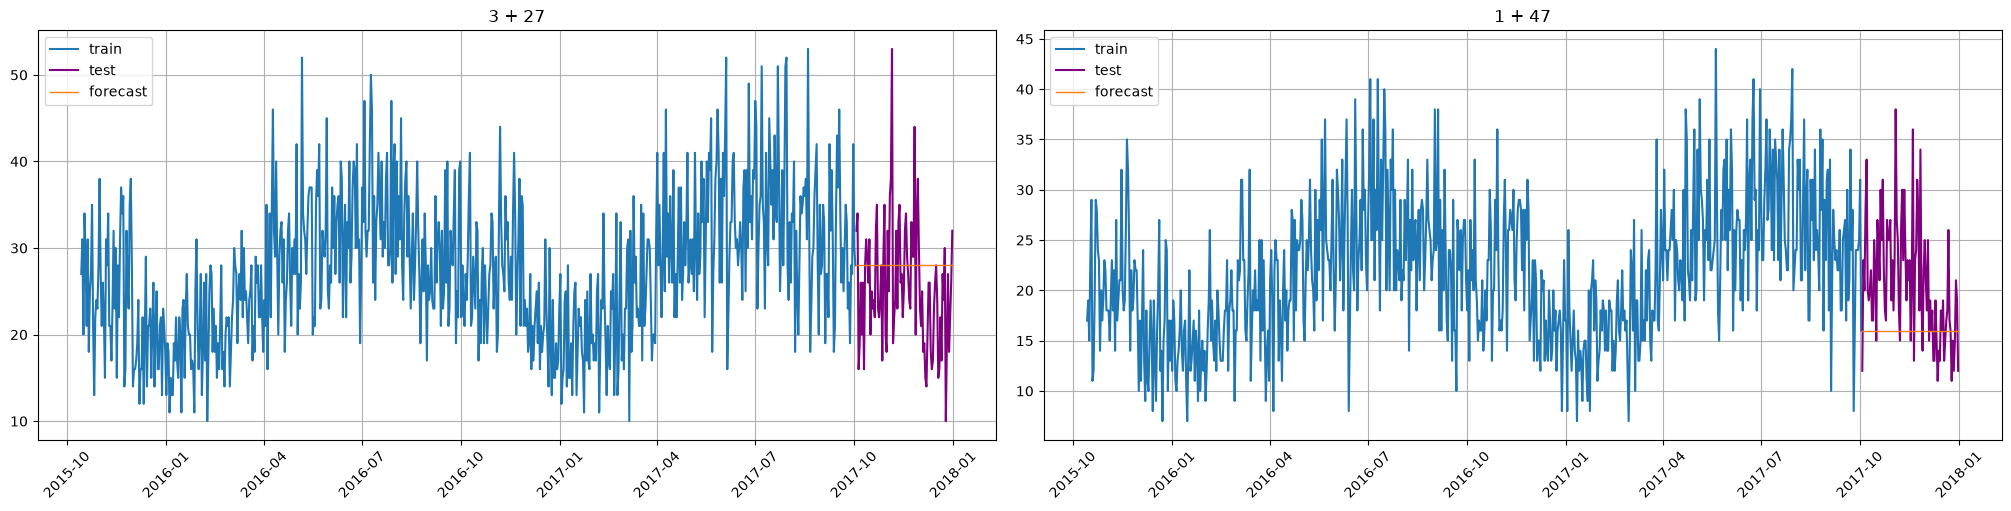

In [27]:
from etna.models import NaiveModel

naive_model_NON_recursive_metrics = train_and_evaluate_model(
    ts=ts,
    model=NaiveModel(),
    transforms=[],
    horizon=HORIZON,
    metrics=smape,
    is_auto_regressive=False,
    print_metrics=True,
    )

# 1. Linear Model

Avg (by segments) metric SMAPE(mode = 'per-segment', missing_mode = 'error', ) is: 19.218795080889127


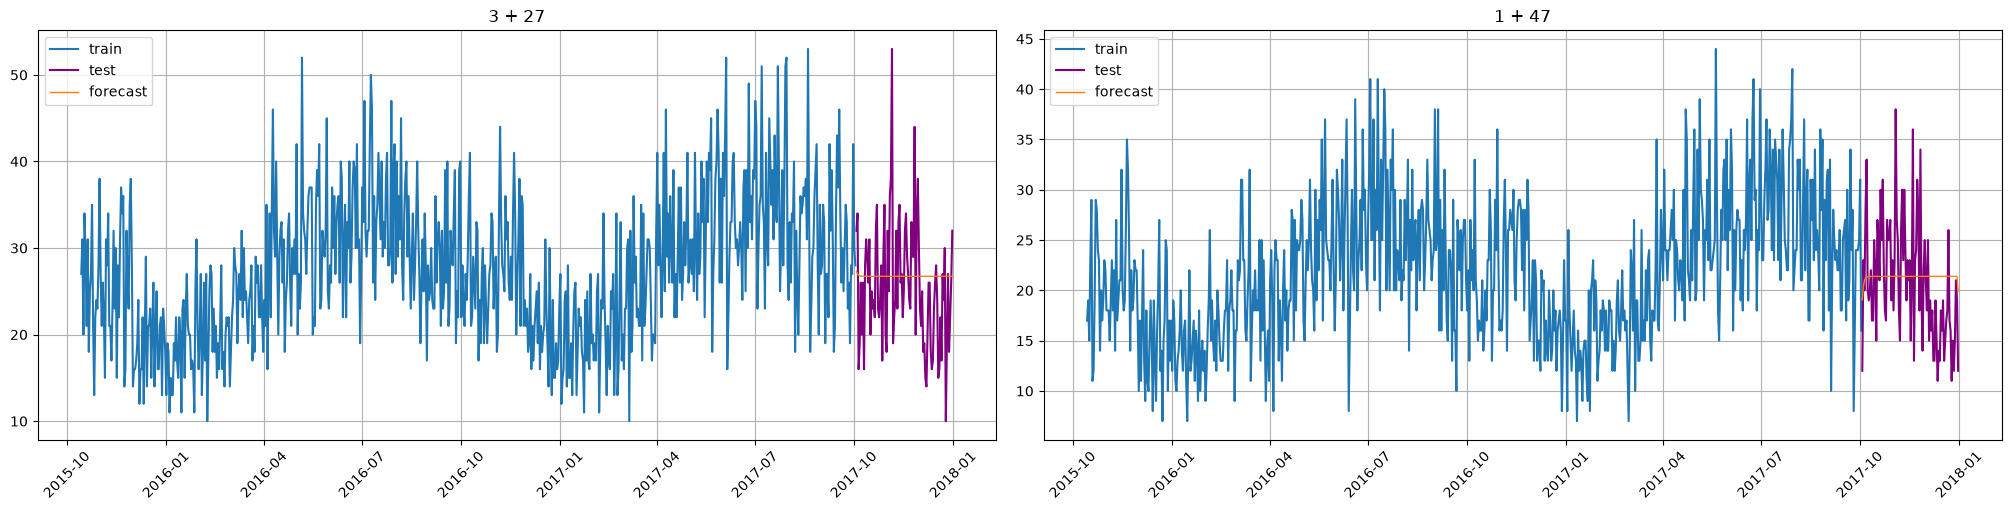

In [28]:
# занимает ~10 минут, так как мы используем рекурсивный пайплайн (который работает медленно)
from etna.models import ElasticPerSegmentModel

lags = LagTransform(
    in_column='target',
    lags=[1],
    out_column='lag'
)

mean7 = MeanTransform(
    in_column='target',
    window=7,
    out_column='mean_7'
)

standardscaler = StandardScalerTransform(
    in_column=['lag_1', 'mean_7']
)

elast_transforms = [
    lags,
    mean7,
    standardscaler
]

linear_model_metrics = train_and_evaluate_model(
    ts=ts,
    model=ElasticPerSegmentModel(
        l1_ratio=0,
        alpha=0,
        random_state=42
    ),
    transforms=elast_transforms,
    horizon=HORIZON,
    metrics=smape,
    is_auto_regressive=True,
    print_metrics=True
)

# Conclusion

In [29]:
model_res = {
    'naive_model_recursive_metrics': naive_model_recursive_metrics,
    'linear_model_metrics': linear_model_metrics,
}

res = pd.DataFrame({'model': list(model_res.keys()),
                    'avg_metric': [model_res[model][1] for model in model_res.keys()],
                    'segment_metrics': [model_res[model][0] for model in model_res.keys()]})

In [30]:
res

,model,avg_metric,segment_metrics
0,naive_model_recursive_metrics,27.941743,1 + 1 50.912771 1 + 10 19.040035 1 + 11...
1,linear_model_metrics,19.218795,1 + 1 24.093210 1 + 10 18.726604 1 + 11...


## Backtest

In [32]:
from etna.pipeline import AutoRegressivePipeline
from etna.models import ElasticPerSegmentModel

pipe = AutoRegressivePipeline(
    model=ElasticPerSegmentModel(
        l1_ratio=0,
        alpha=0,
        random_state=42
    ),
    transforms=elast_transforms,
    horizon=HORIZON
)

In [33]:
# тоже выполняется порядка 10 минут

backtest_result = pipe.backtest(
    mode='expand',
    n_folds=5,
    ts=ts,
    metrics=[smape],
    aggregate_metrics=True,
    joblib_params=dict(backend='loky'),
    n_jobs=-1
)

if isinstance(backtest_result, tuple):
    metrics_df = backtest_result[0]
else:
    metrics_df = backtest_result

metrics_df

{'metrics':     segment      SMAPE
 0     1 + 1  26.357420
 1    1 + 10  22.389953
 2    1 + 11  22.624079
 3    1 + 12  22.476386
 4    1 + 13  21.736752
 ..      ...        ...
 145  3 + 50  20.819818
 146   3 + 6  22.112419
 147   3 + 7  21.572119
 148   3 + 8  21.421719
 149   3 + 9  21.706542
 
 [150 rows x 2 columns],
 'forecasts': [segment    1 + 1                                                          \
  feature     item      lag_1     mean_7 quarter quarter_end quarter_start   
  timestamp                                                                  
  2016-10-08     1  19.000000  21.739249       4       False         False   
  2016-10-09     1  20.174744  20.979613       4       False         False   
  2016-10-10     1  20.682548  21.108478       4       False         False   
  2016-10-11     1  20.902054  20.108041       4       False         False   
  2016-10-12     1  20.996940  20.684892       4       False         False   
  ...          ...        ...        

In [34]:
metrics_df = backtest_result['metrics']

metrics_df.head(8)

,segment,SMAPE
0,1 + 1,26.357420
1,1 + 10,22.389953
2,1 + 11,22.624079
3,1 + 12,22.476386
4,1 + 13,21.736752
5,1 + 14,21.903285
6,1 + 15,21.246919
7,1 + 16,26.646529


In [35]:
metric = metrics_df['SMAPE'].mean()
print(f'mean SMAPE: {metric:.4f}')

mean SMAPE: 22.8238


## Задание
-  Добейтесь значения метрики **SMAPE** меньше 12% (метрика на тесте, отложенной выборке).
-  Оцените качество моделей на backtest-е.
-  Сравните рассмотренные модели между собой, объединив результаты в таблицу `res`, как это было сделано выше.
-  Опишите проделанную работу и сделайте выводы о том, как выбирали гиперпараметры, с какими сложностями столкнулись, какие модели оказались лучше и почему.
-  Используйте и подберите параметры для моделей Prophet, ARIMA, Catboost.

Avg (by segments) metric SMAPE(mode = 'per-segment', missing_mode = 'error', ) is: 11.86582390549867


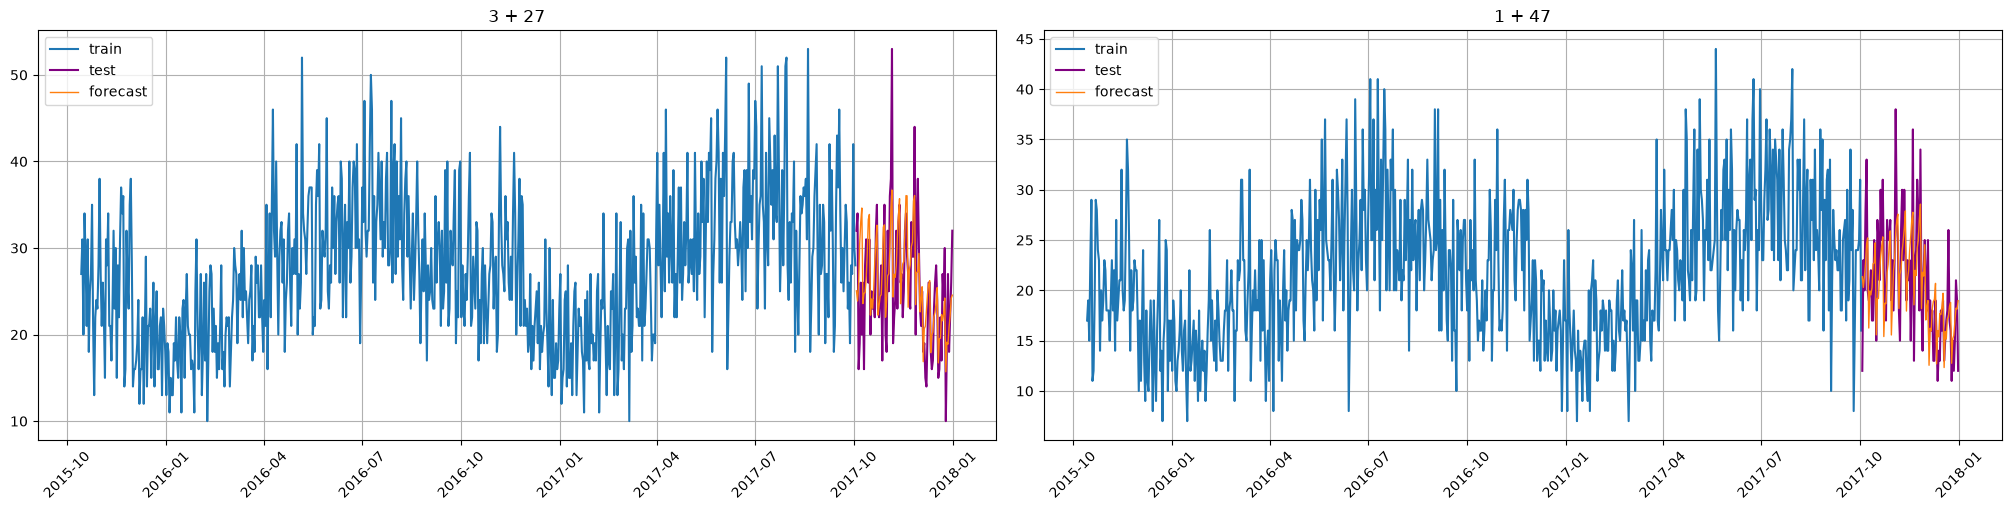

In [36]:
from etna.models import CatBoostMultiSegmentModel
from etna.transforms import (
    LagTransform,
    MeanTransform,
    DateFlagsTransform
)

# Лаговые признаки, Модель будет видеть продажи за прошлые дни:
# вчера, неделю назад, две недели назад и т.д.
catboost_lags = LagTransform(
    in_column='target',
    lags=[1, 2, 3, 7, 14, 21, 28, 56, 91, 182, 364],
    out_column='lag'
)

# Скользящие срение
# Помогают модели понимать локальный уровень спроса
mean_7 = MeanTransform(
    in_column='target',
    window=7,
    out_column='mean_7'
)

mean_14 = MeanTransform(
    in_column='target',
    window=14,
    out_column='mean_14'
)

mean_28 = MeanTransform(
    in_column='target',
    window=28,
    out_column='mean_28'
)

# Календарные признаки
# Дают модели информацию о дне недели, месяце, выходных и т.д.
date_flags = DateFlagsTransform(
    day_number_in_week=True,
    day_number_in_month=True,
    week_number_in_month=True,
    month_number_in_year=True,
    year_number=True,
    special_days_in_week=[],
    out_column='date_flags'
)

catboost_transforms = [
    catboost_lags,
    mean_7,
    mean_14,
    mean_28,
    date_flags
]

catboost_model = CatBoostMultiSegmentModel(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='RMSE',
    random_seed=42
)

catboost_metrics = train_and_evaluate_model(
    ts=ts,
    model=catboost_model,
    transforms=catboost_transforms,
    horizon=HORIZON,
    metrics=smape,
    is_auto_regressive=True,
    print_metrics=True,
    return_forecast=False
)

In [37]:
# Backtest для лучшей модели CatBoost

catboost_pipe = AutoRegressivePipeline(
    model=CatBoostMultiSegmentModel(
        iterations=500,
        depth=6,
        learning_rate=0.05,
        loss_function='RMSE',
        random_seed=42
    ),
    transforms=catboost_transforms,
    horizon=HORIZON
)

catboost_backtest_result = catboost_pipe.backtest(
    mode='expand',
    n_folds=5,
    ts=ts,
    metrics=[smape],
    aggregate_metrics=True,
    joblib_params=dict(backend='loky'),
    n_jobs=-1
)

if isinstance(catboost_backtest_result, tuple):
    catboost_backtest_metrics = catboost_backtest_result[0]
else:
    catboost_backtest_metrics = catboost_backtest_result

# на тот случай если ETNA backtest вернет dict
if isinstance(catboost_backtest_metrics, dict):
    catboost_backtest_metrics_df = catboost_backtest_metrics['metrics']
else:
    catboost_backtest_metrics_df = catboost_backtest_metrics

catboost_backtest_metrics_df.head()

,segment,SMAPE
0,1 + 1,18.783777
1,1 + 10,10.256260
2,1 + 11,9.903674
3,1 + 12,9.847804
4,1 + 13,8.714817


10:28:05 - cmdstanpy - INFO - Chain [1] start processing
10:28:05 - cmdstanpy - INFO - Chain [1] done processing
10:28:05 - cmdstanpy - INFO - Chain [1] start processing
10:28:06 - cmdstanpy - INFO - Chain [1] done processing
10:28:06 - cmdstanpy - INFO - Chain [1] start processing
10:28:06 - cmdstanpy - INFO - Chain [1] done processing
10:28:06 - cmdstanpy - INFO - Chain [1] start processing
10:28:06 - cmdstanpy - INFO - Chain [1] done processing
10:28:06 - cmdstanpy - INFO - Chain [1] start processing
10:28:06 - cmdstanpy - INFO - Chain [1] done processing
10:28:06 - cmdstanpy - INFO - Chain [1] start processing
10:28:06 - cmdstanpy - INFO - Chain [1] done processing
10:28:07 - cmdstanpy - INFO - Chain [1] start processing
10:28:07 - cmdstanpy - INFO - Chain [1] done processing
10:28:07 - cmdstanpy - INFO - Chain [1] start processing
10:28:07 - cmdstanpy - INFO - Chain [1] done processing
10:28:07 - cmdstanpy - INFO - Chain [1] start processing
10:28:07 - cmdstanpy - INFO - Chain [1]

Avg (by segments) metric SMAPE(mode = 'per-segment', missing_mode = 'error', ) is: 12.518267203073771


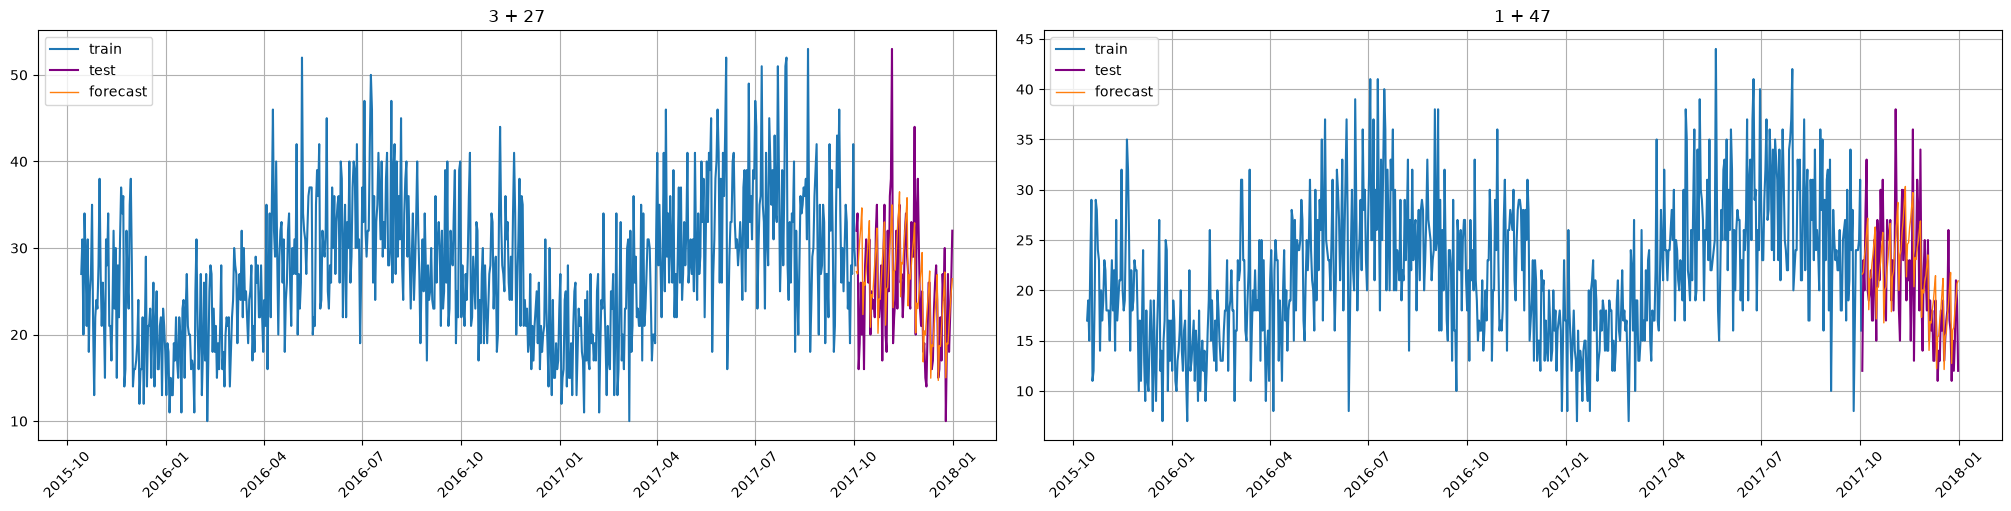

In [38]:
from etna.models import ProphetModel

prophet_metrics = train_and_evaluate_model(
    ts=ts,
    model=ProphetModel(
        growth='linear',
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=True,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.1,
        seasonality_prior_scale=10
    ),
    transforms=[],
    horizon=HORIZON,
    metrics=smape,
    is_auto_regressive=False,
    print_metrics=True
)

In [40]:
# Совместимость ETNA/pmdarima со свежей версией scikit-learn
import sklearn.utils.validation as sklearn_validation

_original_check_array = sklearn_validation.check_array

def check_array_compat(*args, **kwargs):
    if "force_all_finite" in kwargs:
        kwargs["ensure_all_finite"] = kwargs.pop("force_all_finite")
    return _original_check_array(*args, **kwargs)

sklearn_validation.check_array = check_array_compat

# ETNA/pmdarima могли импортировать check_array напрямую,
# поэтому дополнительно патчим функцию внутри модуля ETNA.
import etna.libs.pmdarima_utils.arima as etna_arima_utils

etna_arima_utils.check_array = check_array_compat

Avg (by segments) metric SMAPE(mode = 'per-segment', missing_mode = 'error', ) is: 19.2168784696959


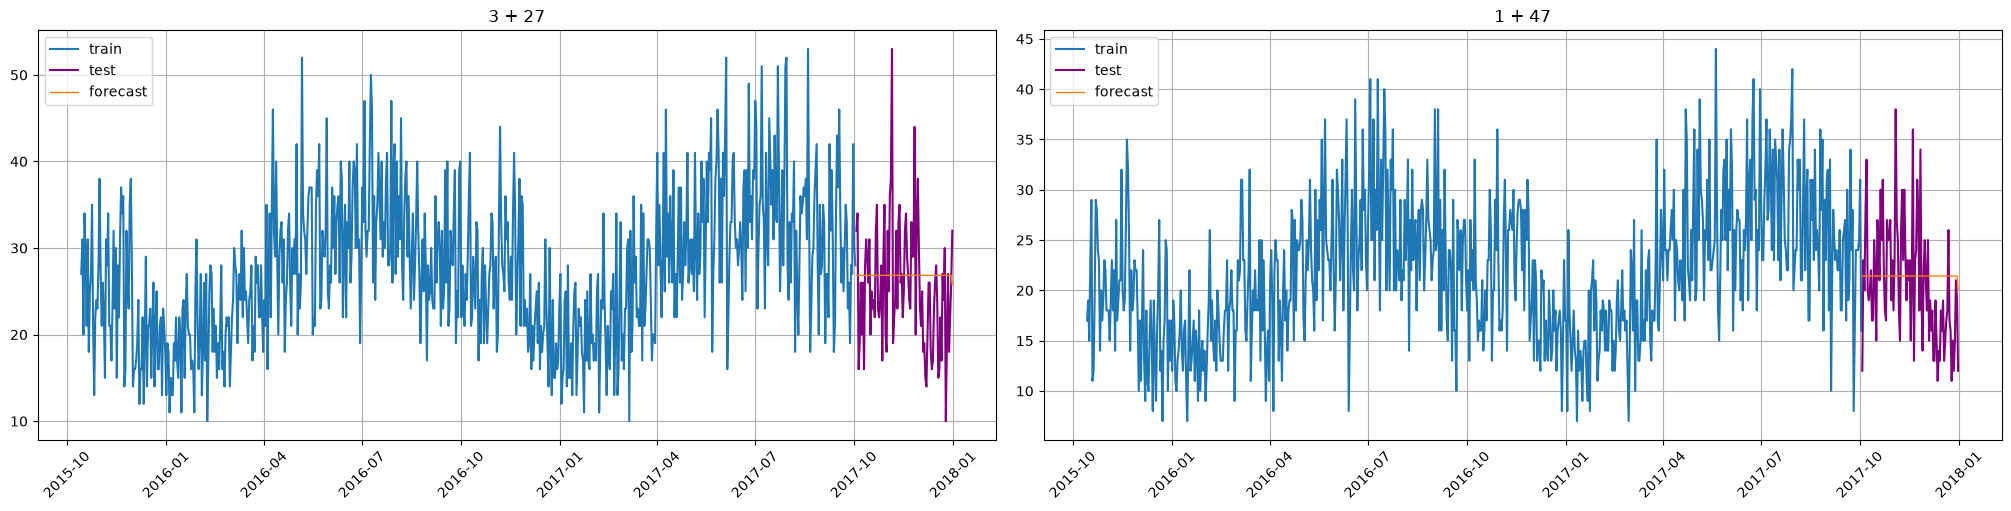

In [41]:
from etna.models import AutoARIMAModel

arima_metrics = train_and_evaluate_model(
    ts=ts,
    model=AutoARIMAModel(),
    transforms=[],
    horizon=HORIZON,
    metrics=smape,
    is_auto_regressive=False,
    print_metrics=True
)

In [42]:
model_res = {
    'naive_model_recursive_metrics': naive_model_recursive_metrics,
    'linear_model_metrics': linear_model_metrics,
    'prophet_model_metrics': prophet_metrics,
    'arima_model_metrics': arima_metrics,
    'catboost_model_metrics': catboost_metrics,
}

res = pd.DataFrame({
    'model': list(model_res.keys()),
    'avg_metric': [model_res[model][1] for model in model_res.keys()],
    'segment_metrics': [model_res[model][0] for model in model_res.keys()]
})

res = res.sort_values('avg_metric').reset_index(drop=True)

res

,model,avg_metric,segment_metrics
0,catboost_model_metrics,11.865824,1 + 1 20.473809 1 + 10 10.751712 1 + 11...
1,prophet_model_metrics,12.518267,1 + 1 20.112006 1 + 10 11.655946 1 + 11...
2,arima_model_metrics,19.216878,1 + 1 24.456809 1 + 10 18.792331 1 + 11...
3,linear_model_metrics,19.218795,1 + 1 24.093210 1 + 10 18.726604 1 + 11...
4,naive_model_recursive_metrics,27.941743,1 + 1 50.912771 1 + 10 19.040035 1 + 11...


## Вывод

В работе была решена задача мультисегментного прогнозирования спроса. Каждый сегмент соответствует паре магазин-товар, например store + item. Для ускорения экспериментов были оставлены только магазины 1, 2 и 3.

По заданию были обучены модели ProphetModel и AutoARIMAModel. Prophet показал SMAPE 12.52, то есть оказался близок к требуемому порогу, но не смог превзойти CatBoost. ARIMA получила SMAPE 19.22, что примерно соответствует качеству линейной модели.

Лучший результат на отложенной тестовой выборке показала модель CatBoostMultiSegmentModel. Для неё использовались лаги, скользящие средние и календарные признаки. Средняя SMAPE составила 11.87, что ниже требуемого порога 12%.

Для итоговой лучшей модели CatBoost был дополнительно выполнен backtest на нескольких фолдах. Это позволило проверить качество модели не только на одном отложенном периоде, но и на нескольких последовательных временных разбиениях.

Итоговая таблица сравнения показала, что CatBoost оказался лучшей моделью среди рассмотренных. Он лучше учитывает нелинейные зависимости между лагами, календарными признаками и продажами, поэтому превзошёл NaiveModel, линейную модель, Prophet и ARIMA.